In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

Цель работы — выполнить кластерный анализ Leaf Dataset.

Объекты — отдельные экземпляры листьев.

Признаки — количественные морфометрические и текстурные характеристики.

Метод — максимально удалённые эталоны.

Цель кластеризации:

Разбить множество листьев на k однородных групп (кластеров), где:

Объекты внутри одного кластера максимально похожи по морфометрическим признакам

Объекты из разных кластеров максимально отличаются

Кластеры имеют биологическую интерпретируемость

Источник данных:
https://archive.ics.uci.edu/dataset/288/leaf

In [2]:
data = "../data/leaf.csv"

columns_ru = [
    "класс_листа",
    "номер_образца",
    "эксцентриситет",
    "отношение_сторон",
    "вытянутость",
    "плотность_формы",
    "стохастическая_выпуклость",
    "изопериметрический_фактор",
    "максимальная_глубина_вырезов",
    "лопастность",
    "средняя_интенсивность",
    "средний_контраст",
    "гладкость",
    "третий_момент",
    "однородность",
    "энтропия"
]

df = pd.read_csv(data, header=None, names=columns_ru)

df.head()

,класс_листа,номер_образца,эксцентриситет,отношение_сторон,вытянутость,плотность_формы,стохастическая_выпуклость,изопериметрический_фактор,максимальная_глубина_вырезов,лопастность,средняя_интенсивность,средний_контраст,гладкость,третий_момент,однородность,энтропия
0,1,1,0.72694,1.4742,0.32396,0.98535,1.00000,0.83592,0.004657,0.003947,0.047790,0.127950,0.016108,0.005232,0.000275,1.17560
1,1,2,0.74173,1.5257,0.36116,0.98152,0.99825,0.79867,0.005242,0.005002,0.024160,0.090476,0.008119,0.002708,0.000075,0.69659
2,1,3,0.76722,1.5725,0.38998,0.97755,1.00000,0.80812,0.007457,0.010121,0.011897,0.057445,0.003289,0.000921,0.000038,0.44348
3,1,4,0.73797,1.4597,0.35376,0.97566,1.00000,0.81697,0.006877,0.008607,0.015950,0.065491,0.004271,0.001154,0.000066,0.58785
4,1,5,0.82301,1.7707,0.44462,0.97698,1.00000,0.75493,0.007428,0.010042,0.007938,0.045339,0.002051,0.000560,0.000024,0.34214


In [3]:
print("Размерность датасета:", df.shape)
print("Количество объектов:", df.shape[0])
print("Количество признаков:", df.shape[1])

Размерность датасета: (340, 16)
Количество объектов: 340
Количество признаков: 16


In [4]:
X = df.drop(columns=["класс_листа", "номер_образца"])
X.head()

,эксцентриситет,отношение_сторон,вытянутость,плотность_формы,стохастическая_выпуклость,изопериметрический_фактор,максимальная_глубина_вырезов,лопастность,средняя_интенсивность,средний_контраст,гладкость,третий_момент,однородность,энтропия
0,0.72694,1.4742,0.32396,0.98535,1.00000,0.83592,0.004657,0.003947,0.047790,0.127950,0.016108,0.005232,0.000275,1.17560
1,0.74173,1.5257,0.36116,0.98152,0.99825,0.79867,0.005242,0.005002,0.024160,0.090476,0.008119,0.002708,0.000075,0.69659
2,0.76722,1.5725,0.38998,0.97755,1.00000,0.80812,0.007457,0.010121,0.011897,0.057445,0.003289,0.000921,0.000038,0.44348
3,0.73797,1.4597,0.35376,0.97566,1.00000,0.81697,0.006877,0.008607,0.015950,0.065491,0.004271,0.001154,0.000066,0.58785
4,0.82301,1.7707,0.44462,0.97698,1.00000,0.75493,0.007428,0.010042,0.007938,0.045339,0.002051,0.000560,0.000024,0.34214


In [5]:
#нормализация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

В качестве меры расстояния между объектами использовано косинусное расстояние. Данная мера позволяет оценивать сходство объектов по направлению в пространстве признаков. Это особенно важно при анализе морфометрических характеристик листьев, где ключевую роль играют относительные пропорции признаков, а не их абсолютные значения.

### Косинусное расстояние

Для оценки близости объектов используется косинусное расстояние, основанное на угле между векторами признаков.

Косинусное сходство определяется формулой:
$$
\cos(\mathbf{x}, \mathbf{y}) =
\frac{\mathbf{x} \cdot \mathbf{y}}
{\|\mathbf{x}\| \, \|\mathbf{y}\|}
$$

где $\mathbf{x}$ и $\mathbf{y}$ — векторы признаков объектов.

Косинусное расстояние вычисляется как:
$$
d_{\cos}(\mathbf{x}, \mathbf{y}) = 1 - \cos(\mathbf{x}, \mathbf{y})
$$


In [6]:
from scipy.spatial.distance import pdist, squareform

distance_metric = "cosine"

distance_matrix = squareform(pdist(X_scaled, metric=distance_metric))


In [7]:
#матрица объект-объект
distance_matrix = squareform(pdist(X_scaled, metric="cosine"))

print("Размерность матрицы расстояний:", distance_matrix.shape)
pd.DataFrame(distance_matrix[:5, :5])

Размерность матрицы расстояний: (340, 340)


,0,1,2,3,4
0,0.000000,0.198703,0.366153,0.297412,0.476768
1,0.198703,0.000000,0.033657,0.016942,0.080057
2,0.366153,0.033657,0.000000,0.006718,0.013406
3,0.297412,0.016942,0.006718,0.000000,0.037310
4,0.476768,0.080057,0.013406,0.037310,0.000000


In [8]:
#матрица объект–признак
object_feature_matrix = X.copy()

print("Матрица «объект–признак» (фрагмент):")
display(object_feature_matrix.head())

print("\nРазмерность матрицы «объект–признак»:", object_feature_matrix.shape)

Матрица «объект–признак» (фрагмент):


,эксцентриситет,отношение_сторон,вытянутость,плотность_формы,стохастическая_выпуклость,изопериметрический_фактор,максимальная_глубина_вырезов,лопастность,средняя_интенсивность,средний_контраст,гладкость,третий_момент,однородность,энтропия
0,0.72694,1.4742,0.32396,0.98535,1.00000,0.83592,0.004657,0.003947,0.047790,0.127950,0.016108,0.005232,0.000275,1.17560
1,0.74173,1.5257,0.36116,0.98152,0.99825,0.79867,0.005242,0.005002,0.024160,0.090476,0.008119,0.002708,0.000075,0.69659
2,0.76722,1.5725,0.38998,0.97755,1.00000,0.80812,0.007457,0.010121,0.011897,0.057445,0.003289,0.000921,0.000038,0.44348
3,0.73797,1.4597,0.35376,0.97566,1.00000,0.81697,0.006877,0.008607,0.015950,0.065491,0.004271,0.001154,0.000066,0.58785
4,0.82301,1.7707,0.44462,0.97698,1.00000,0.75493,0.007428,0.010042,0.007938,0.045339,0.002051,0.000560,0.000024,0.34214



Размерность матрицы «объект–признак»: (340, 14)


In [9]:
def cosine_distance_matrix(X, y):
    X_norm = X / np.linalg.norm(X, axis=1, keepdims=True)
    y_norm = y / np.linalg.norm(y)
    cosine_similarity = np.dot(X_norm, y_norm)
    return 1 - cosine_similarity

def algorithm_45_farthest_prototypes(Xn, k, seed=42):
    rng = np.random.default_rng(seed)
    n = Xn.shape[0]

    # 1. Выбор первого эталона
    prototypes = [int(rng.integers(0, n))]

    # 2. Последовательный выбор остальных эталонов
    for _ in range(1, k):
        distances = np.vstack([
            cosine_distance_matrix(Xn, Xn[p])
            for p in prototypes
        ])
        min_distances = distances.min(axis=0)
        next_proto = int(np.argmax(min_distances))
        prototypes.append(next_proto)

    # 3. Назначение объектов ближайшему эталону
    distances_to_prototypes = np.vstack([
        cosine_distance_matrix(Xn, Xn[p])
        for p in prototypes
    ]).T

    labels = np.argmin(distances_to_prototypes, axis=1)

    return labels, prototypes

In [10]:
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

In [11]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

rows = []
for k in range(2, 11):
    labels_k, _ = algorithm_45_farthest_prototypes(X_scaled, k, seed=42)
    unique, counts = np.unique(labels_k, return_counts=True)
    if counts.min() < 2:
        rows.append({"k": k, "silhouette": np.nan, "calinski_harabasz": np.nan, "davies_bouldin": np.nan})
        continue

    rows.append({
        "k": k,
        "silhouette": silhouette_score(X_scaled, labels_k),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels_k),  # больше = лучше
        "davies_bouldin": davies_bouldin_score(X_scaled, labels_k)         # меньше = лучше
    })

k_table = pd.DataFrame(rows)
k_table

,k,silhouette,calinski_harabasz,davies_bouldin
0,2,0.211448,100.080986,1.698178
1,3,0.257212,126.164330,1.305222
2,4,0.217791,97.745988,1.763234
3,5,0.164491,87.834671,1.635571
4,6,0.166865,85.841768,1.629509
5,7,0.183579,91.056021,1.559649
6,8,0.170731,86.072113,1.539503
7,9,0.176178,85.813838,1.429939
8,10,0.181447,83.747010,1.469016


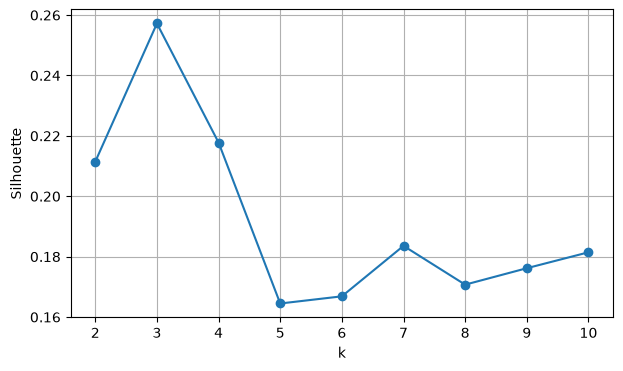

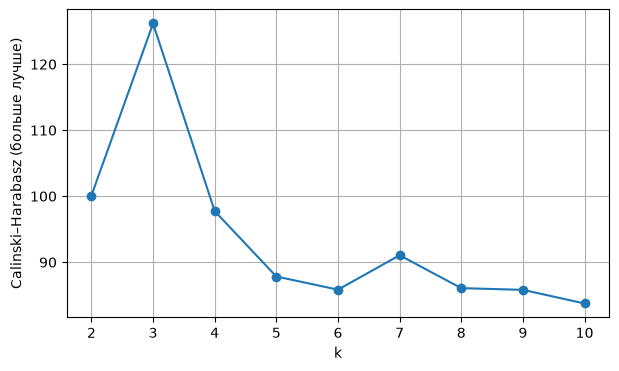

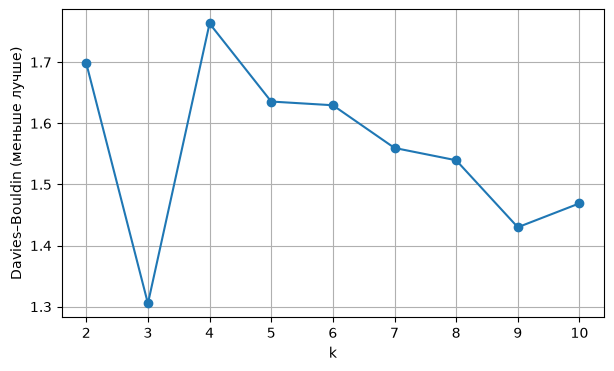

In [12]:
plt.figure(figsize=(7,4))
plt.plot(k_table["k"], k_table["silhouette"], marker="o")
plt.xlabel("k"); plt.ylabel("Silhouette"); plt.grid(True); plt.show()

plt.figure(figsize=(7,4))
plt.plot(k_table["k"], k_table["calinski_harabasz"], marker="o")
plt.xlabel("k"); plt.ylabel("Calinski–Harabasz (больше лучше)"); plt.grid(True); plt.show()

plt.figure(figsize=(7,4))
plt.plot(k_table["k"], k_table["davies_bouldin"], marker="o")
plt.xlabel("k"); plt.ylabel("Davies–Bouldin (меньше лучше)"); plt.grid(True); plt.show()

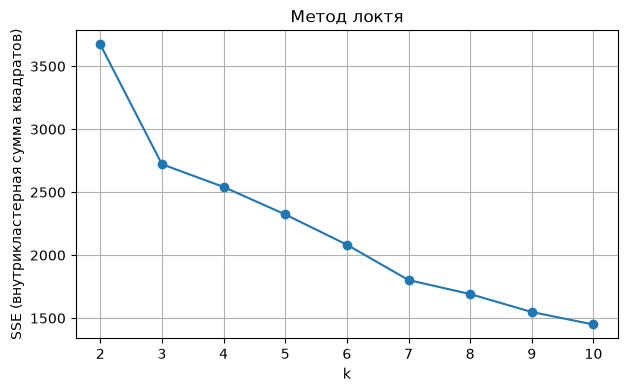

,k,sse
0,2,3672.562955
1,3,2721.944664
2,4,2541.741103
3,5,2323.342747
4,6,2083.099556
5,7,1802.587144
6,8,1691.077475
7,9,1548.445630
8,10,1449.447759


In [13]:
def sse_for_labels(Xn, labels):
    sse = 0.0
    for c in np.unique(labels):
        pts = Xn[labels == c]
        center = pts.mean(axis=0)  # центр для оценки компактности (только для метрики, не для алгоритма)
        sse += ((pts - center) ** 2).sum()
    return float(sse)

rows = []
for k in range(2, 11):
    labels_k, _ = algorithm_45_farthest_prototypes(X_scaled, k, seed=42)
    rows.append({"k": k, "sse": sse_for_labels(X_scaled, labels_k)})

sse_table = pd.DataFrame(rows)

plt.figure(figsize=(7,4))
plt.plot(sse_table["k"], sse_table["sse"], marker="o")
plt.xlabel("k"); plt.ylabel("SSE (внутрикластерная сумма квадратов)")
plt.title("Метод локтя")
plt.grid(True)
plt.show()

sse_table

По совокупности критериев качества — коэффициента силуэта, индексов Calinski–Harabasz и Davies–Bouldin, а также метода локтя - оптимальным числом кластеров является k = 3.

In [14]:
k = 3

labels_3, prototypes_3 = algorithm_45_farthest_prototypes(
    X_scaled,
    k=k,
    seed=42
)

print("Число кластеров k =", k)


Число кластеров k = 3


In [15]:
import pandas as pd
import numpy as np

cluster_sizes = pd.Series(labels_3).value_counts().sort_index()
cluster_sizes

0    110
1    103
2    127
Name: count, dtype: int64

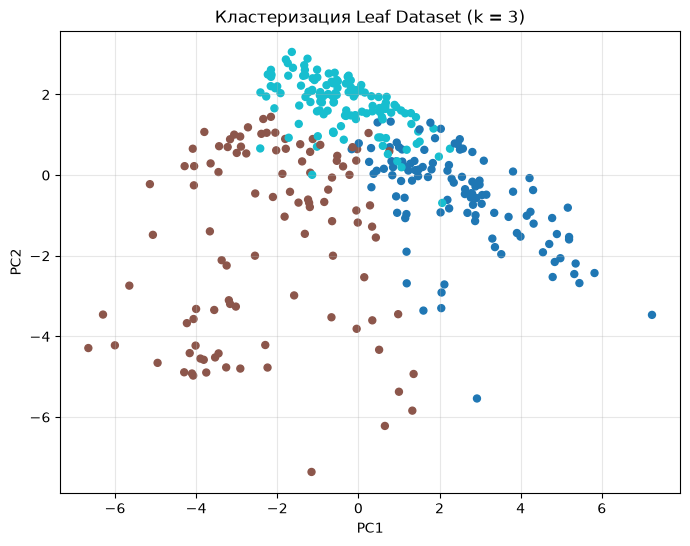

In [16]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_3, cmap="tab10", s=25)
plt.title("Кластеризация Leaf Dataset (k = 3)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.show()

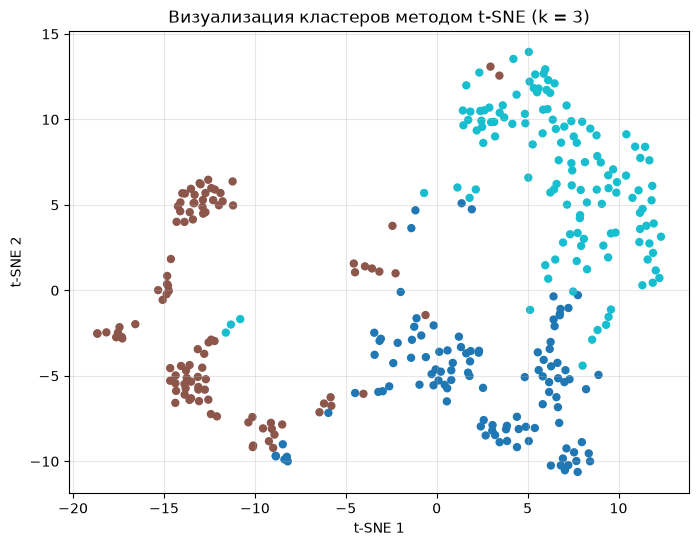

In [17]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,
    metric="cosine",
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=labels_3,
    cmap="tab10",
    s=25
)
plt.title("Визуализация кластеров методом t-SNE (k = 3)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
import pandas as pd
import numpy as np

df_feat = X.copy()
df_feat["Кластер"] = labels_3

# Средние по кластерам
cluster_means = df_feat.groupby("Кластер").mean()

# Общие средние и стандартное отклонение
global_mean = X.mean()
global_std = X.std()

# Z-score средних значений
cluster_z = (cluster_means - global_mean) / global_std

cluster_z

,эксцентриситет,отношение_сторон,вытянутость,плотность_формы,стохастическая_выпуклость,изопериметрический_фактор,максимальная_глубина_вырезов,лопастность,средняя_интенсивность,средний_контраст,гладкость,третий_момент,однородность,энтропия
Кластер,,,,,,,,,,,,,,
0,-0.065540,-0.262437,-0.294810,0.281966,0.344803,0.239920,-0.239944,-0.298770,1.088409,1.110268,1.106393,1.025295,0.782092,0.957165
1,0.161269,0.669897,1.086403,-0.957076,-0.902981,-1.230360,0.965732,0.858230,-0.427879,-0.394205,-0.405649,-0.352709,-0.439212,-0.377915
2,-0.074027,-0.315995,-0.625751,0.531988,0.433690,0.790047,-0.575405,-0.437268,-0.595696,-0.641940,-0.629302,-0.601996,-0.321191,-0.522543


1. Эксцентриситет

Характеризует степень вытянутости формы листа относительно главной оси.
— малые значения соответствуют округлым формам
— большие значения — сильно вытянутым

2. Отношение длины к ширине

Показывает пропорции листа.
— высокие значения означают узкие и длинные листья
— низкие — более широкие и компактные

3. Вытянутость

Обобщённая характеристика удлинённости формы.
Используется для оценки преобладания одной геометрической оси над другой.

4. Плотность формы

Показывает, насколько форма листа близка к компактной, цельной фигуре.
— высокие значения характерны для простых, гладких форм
— низкие — для форм с вырезами и неровным контуром

5. Стохастическая выпуклость

Оценивает степень выпуклости контура листа с учётом случайных отклонений.
— высокие значения соответствуют гладким, выпуклым формам
— низкие — сложным, вогнутым формам

6. Изопериметрический фактор

Мера компактности, связывающая площадь и периметр фигуры.
— высокие значения характерны для округлых форм
— низкие — для вытянутых или неровных

7. Максимальная глубина вырезов

Отражает максимальную глубину вогнутых участков контура.
Используется для оценки выраженности вырезов и лопастей.

8. Лопастность

Характеризует степень расчленённости формы листа.
— высокие значения соответствуют лопастным, сильно расчленённым листьям
— низкие — цельным формам

Текстурные признаки изображения листа

(описывают распределение яркости и структурные особенности изображения)

9. Средняя интенсивность

Среднее значение яркости изображения листа.
Используется как базовая характеристика визуальной насыщенности.

10. Средний контраст

Показывает степень различий между соседними участками изображения.
— высокие значения соответствуют резким переходам яркости
— низкие — плавным изменениям

11. Гладкость

Характеризует степень однородности изображения.
— высокая гладкость — мало резких изменений
— низкая — наличие мелких деталей и шумов

12. Третий момент

Описывает асимметрию распределения яркости.
Используется для выявления перекосов в структуре изображения.

13. Однородность

Показывает, насколько равномерно распределена яркость по изображению.
— высокие значения — однородная текстура
— низкие — выраженная неоднородность

14. Энтропия

Мера сложности и разнообразия текстуры изображения.
— высокая энтропия — сложная, насыщенная структура
— низкая — простая и регулярная

Первый кластер характеризуется компактной формой и высокой насыщенностью изображения.

Второй — вытянутой формой с выраженной сложностью контура.

Третий — компактной ближе к округлой и простой формой.

In [19]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

sil = silhouette_score(X_scaled, labels_3, metric="cosine")
ch  = calinski_harabasz_score(X_scaled, labels_3)
db  = davies_bouldin_score(X_scaled, labels_3)

print("Оценка качества при k = 3:")
print("Silhouette (cosine):", round(sil, 3))
print("Calinski–Harabasz:", round(ch, 2))
print("Davies–Bouldin:", round(db, 3))

Оценка качества при k = 3:
Silhouette (cosine): 0.475
Calinski–Harabasz: 126.16
Davies–Bouldin: 1.305


В результате кластеризации Leaf Dataset методом максимально удалённых эталонов при k = 3 получено устойчивое и хорошо интерпретируемое разбиение выборки. Визуализация методом PCA и t-SNE, а также значения коэффициента силуэта и индексов Calinski–Harabasz и Davies–Bouldin подтверждают высокое качество кластеризации и обоснованность выбора числа кластеров.